# Multi-State Credit Risk Model — Freddie Mac

Questo notebook adatta l'esempio COVID-19 (`pymsm`) al dataset **Freddie Mac Single-Family Loan-Level**.

## Struttura degli stati

```
  ┌─────────────────────────────────────────┐
  │                                         │
  ▼                                         │
[1] Current ──────────────────────────► [3] 60-89 DPD  (terminale)
  │  ▲                                  
  │  │                                  
  ▼  │                                  
[2] 30-59 DPD ────────────────────────► [4] 90+ / Default  (terminale)
```

| Stato | Codice | Descrizione |
|-------|--------|-------------|
| Current | 1 | Mutuo performing, nessun ritardo |
| 30-59 DPD | 2 | Days Past Due 30-59 (potenziale cura) |
| 60-89 DPD | 3 | **Terminale** nel dataset osservato |
| 90+ / Default | 4 | **Terminale** — default conclamato |

**Covariate:** `ltv`, `fico`, `dti`, `interest_rate`, `borrower_sex`, `first_time_buyer`, `loan_purpose_C`, `loan_purpose_N`

## 1. Installazione dipendenze

In [1]:
%pip install pymsm lifelines==0.26.4 numpy==1.26.4 pandas==1.5.3 tabulate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pymsm.multi_state_competing_risks_model import MultiStateModel
from pymsm.statistics import (
    prob_visited_states,
    stats_total_time_at_states,
    get_path_frequencies,
)
from pymsm.simulation import MultiStateSimulator, extract_competing_risks_models_list_from_msm

%load_ext autoreload
%autoreload 2

## 3. Caricamento e preparazione dati

Il file `freddie_mac_long.csv` è un **panel mensile** (una riga per mutuo per mese).
Lo convertiamo nel formato **transizione** richiesto da `pymsm`:
una riga per ogni *soggiorno* in uno stato, con `entry_time` e `exit_time`.

In [35]:
# ── Adatta questo path al tuo ambiente ──
DATA_PATH = "C:\\Users\\aless\\Downloads\\freddie_mac_long.csv"

# Covariate statiche usate sempre (se presenti nel file)
BASE_COVARIATE_COLS = [
    "ltv", "fico", "dti", "interest_rate",
    "borrower_sex", "first_time_buyer",
    "loan_purpose_C", "loan_purpose_N"
]

# Covariate time-varying opzionali: verranno incluse solo se esistono nel CSV
OPTIONAL_TV_SOURCE_COLS = [
    "CurAct_UPB", "CurLoanDel", "LoanAge", "ZeroBalCode",
    "CurIntRate", "CNIB_UPB", "ELTV"
]
OPTIONAL_TV_LAG_COLS = [f"{c}_lag1" for c in OPTIONAL_TV_SOURCE_COLS]

# Lista iniziale; verrà filtrata automaticamente sulle colonne realmente disponibili
COVARIATE_COLS = BASE_COVARIATE_COLS + OPTIONAL_TV_LAG_COLS

STATE_LABELS = {
    1: "Current",
    2: "30-59 DPD",
    3: "60-89 DPD",
    4: "90+ / Default",
}

TERMINAL_STATES = [3, 4]

In [36]:
def panel_to_transitions(
    path: str,
    covariate_cols: list,
    optional_tv_source_cols: list = None,
) -> tuple[pd.DataFrame, list, list]:
    """
    Converte il panel mensile Freddie Mac nel formato transizione richiesto da pymsm.

    Se una colonna time-varying opzionale è presente nel CSV, crea anche la versione lag1.
    """
    df = pd.read_csv(path)
    df = df.sort_values(["sample_id", "time_at_t"]).reset_index(drop=True)

    optional_tv_source_cols = optional_tv_source_cols or []

    # Crea automaticamente le colonne lag1 solo per le variabili disponibili nel dataset
    for src in optional_tv_source_cols:
        if src in df.columns:
            if src == "ZeroBalCode":
                # Encoding numerico per eventuali codici testuali
                df[src] = pd.factorize(df[src].astype(str), sort=True)[0].astype(float)
            lag_col = f"{src}_lag1"
            df[lag_col] = df.groupby("sample_id")[src].shift(1)
            df[lag_col] = df[lag_col].fillna(df[src])

    available_covariates = [c for c in covariate_cols if c in df.columns]
    missing_covariates = [c for c in covariate_cols if c not in df.columns]

    records = []
    for loan_id, group in df.groupby("sample_id", sort=False):
        group = group.reset_index(drop=True)
        entry_idx = 0

        for i in range(1, len(group)):
            curr_state = group.loc[i, "state_at_t"]
            prev_state = group.loc[i - 1, "state_at_t"]

            if curr_state != prev_state:
                # Stato cambiato: registra il soggiorno precedente
                exit_row = group.loc[i - 1]
                rec = {
                    "sample_id": loan_id,
                    "origin_state": int(prev_state),
                    "target_state": (
                        int(exit_row["next_state"])
                        if not pd.isna(exit_row["next_state"])
                        else 0
                    ),
                    "time_entry_to_origin": int(group.loc[entry_idx, "time_at_t"]),
                    "time_transition_to_target": int(group.loc[i, "time_at_t"]),
                }
                for c in available_covariates:
                    rec[c] = group.loc[entry_idx, c]
                records.append(rec)
                entry_idx = i

            # Ultima riga del mutuo -> registra soggiorno finale
            if i == len(group) - 1 and curr_state == prev_state:
                last_row = group.loc[i]
                rec = {
                    "sample_id": loan_id,
                    "origin_state": int(curr_state),
                    "target_state": (
                        0
                        if pd.isna(last_row["next_state"])
                        else int(last_row["next_state"])
                    ),
                    "time_entry_to_origin": int(group.loc[entry_idx, "time_at_t"]),
                    "time_transition_to_target": int(last_row["time_at_t"] + 1),
                }
                for c in available_covariates:
                    rec[c] = group.loc[entry_idx, c]
                records.append(rec)

    return pd.DataFrame(records), available_covariates, missing_covariates


dataset, used_covariates, missing_covariates = panel_to_transitions(
    DATA_PATH,
    COVARIATE_COLS,
    optional_tv_source_cols=OPTIONAL_TV_SOURCE_COLS,
)

# Allinea la lista covariate a quelle realmente disponibili
COVARIATE_COLS = used_covariates

print(f"Transizioni totali: {len(dataset)}")
print(f"Mutui unici:        {dataset['sample_id'].nunique()}")
print()
print(f"Covariate usate ({len(COVARIATE_COLS)}): {COVARIATE_COLS}")
if missing_covariates:
    print(f"Covariate non presenti nel CSV (ignorate): {missing_covariates}")
print()
print("Distribuzione target_state:")
print(dataset["target_state"].value_counts(dropna=False).sort_index())
dataset.head(10)

Transizioni totali: 3897
Mutui unici:        2000

Covariate usate (8): ['ltv', 'fico', 'dti', 'interest_rate', 'borrower_sex', 'first_time_buyer', 'loan_purpose_C', 'loan_purpose_N']
Covariate non presenti nel CSV (ignorate): ['CurAct_UPB_lag1', 'CurLoanDel_lag1', 'LoanAge_lag1', 'ZeroBalCode_lag1', 'CurIntRate_lag1', 'CNIB_UPB_lag1', 'ELTV_lag1']

Distribuzione target_state:
0     103
1     924
2     974
3    1623
4     273
Name: target_state, dtype: int64


,sample_id,origin_state,target_state,time_entry_to_origin,time_transition_to_target,ltv,fico,dti,interest_rate,borrower_sex,first_time_buyer,loan_purpose_C,loan_purpose_N
0,FM0000000,1,3,1,16,76.2,736,38.0,4.479,1,1,0,0
1,FM0000001,1,3,1,5,84.0,662,43.2,4.806,1,0,0,0
2,FM0000002,1,4,1,131,80.0,761,38.2,4.531,0,1,0,0
3,FM0000003,1,2,1,240,77.3,771,53.9,4.399,0,0,0,0
4,FM0000003,2,1,240,243,77.3,771,53.9,4.399,0,0,0,0
5,FM0000003,1,3,243,282,77.3,771,53.9,4.399,0,0,0,0
6,FM0000004,1,2,1,7,84.6,612,47.4,4.204,0,1,1,0
7,FM0000004,2,1,7,8,84.6,612,47.4,4.204,0,1,1,0
8,FM0000004,1,2,8,9,84.6,612,47.4,4.204,0,1,1,0
9,FM0000004,2,1,9,10,84.6,612,47.4,4.204,0,1,1,0


## 4. Funzione di aggiornamento covariate (time-varying)

Questa funzione viene chiamata da `pymsm` ad ogni transizione simulata.
Le covariate statiche (FICO, LTV, DTI...) restano invariate.

> **Estensione suggerita:** aggiungi qui variabili macro (tasso BCE, spread,
> unemployment rate) in funzione del `current_time` se hai quei dati.

In [37]:
def freddie_update_covariates(
    covariates: pd.Series,
    current_state: int,
    next_state: int,
    current_time: float,
    transition_time: float,
) -> pd.Series:
    """
    Aggiorna le covariate dopo una transizione di stato.

    Se una colonna time-varying non esiste nel dataset, viene ignorata.
    """
    updated = covariates.copy()
    dt = float(transition_time)

    if "LoanAge_lag1" in updated.index:
        updated["LoanAge_lag1"] = max(0.0, float(updated["LoanAge_lag1"]) + dt)

    if "CurAct_UPB_lag1" in updated.index:
        # Semplice ammortamento mensile di scenario
        amort = 0.998 ** max(dt, 1.0)
        updated["CurAct_UPB_lag1"] = max(0.0, float(updated["CurAct_UPB_lag1"]) * amort)

    if "CNIB_UPB_lag1" in updated.index:
        carry = 0.999 ** max(dt, 1.0)
        updated["CNIB_UPB_lag1"] = max(0.0, float(updated["CNIB_UPB_lag1"]) * carry)

    if "CurLoanDel_lag1" in updated.index:
        # Mappa stato -> proxy giorni di delinquenza
        delinquency_map = {1: 0.0, 2: 30.0, 3: 60.0, 4: 90.0}
        updated["CurLoanDel_lag1"] = delinquency_map.get(next_state, float(updated["CurLoanDel_lag1"]))

    if "ELTV_lag1" in updated.index:
        # Scenario semplice: peggiora con stati delinquenti, migliora in cura
        eltv = float(updated["ELTV_lag1"])
        if next_state in (2, 3, 4):
            updated["ELTV_lag1"] = eltv * 1.01
        elif next_state == 1:
            updated["ELTV_lag1"] = eltv * 0.995

    # CurIntRate_lag1 e ZeroBalCode_lag1 lasciate stabili se presenti
    return updated

## 5. Fitting del modello multi-stato

In [38]:
multi_state_model = MultiStateModel(
    dataset=dataset,
    competing_risk_data_format=True,
    terminal_states=TERMINAL_STATES,
    update_covariates_fn=freddie_update_covariates,
    covariate_names=COVARIATE_COLS,
    state_labels=STATE_LABELS,
    trim_transitions_threshold=10,  # scarta transizioni con <10 osservazioni
)

multi_state_model.fit()

Fitting Model at State: 1
>>> Fitting Transition to State: 3, n events: 1623


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:997: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  nonnumeric_cols = [col for (col, dtype) in df.dtypes.iteritems() if dtype.name == "category" or dtype.kind not in "biuf"]


>>> Fitting Transition to State: 4, n events: 225


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:997: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  nonnumeric_cols = [col for (col, dtype) in df.dtypes.iteritems() if dtype.name == "category" or dtype.kind not in "biuf"]


>>> Fitting Transition to State: 2, n events: 974


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:997: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  nonnumeric_cols = [col for (col, dtype) in df.dtypes.iteritems() if dtype.name == "category" or dtype.kind not in "biuf"]


Fitting Model at State: 2
>>> Fitting Transition to State: 1, n events: 924
>>> Fitting Transition to State: 4, n events: 48


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:997: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  nonnumeric_cols = [col for (col, dtype) in df.dtypes.iteritems() if dtype.name == "category" or dtype.kind not in "biuf"]
C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\__init__.py:997: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  nonnumeric_cols = [col for (col, dtype) in df.dtypes.iteritems() if dtype.name == "category" or dtype.kind not in "biuf"]


### Matrice di transizione osservata

In [13]:
multi_state_model.transition_table

target_state,Censored,Current,30-59 DPD,60-89 DPD,90+ / Default
origin_state,,,,,
Current,102,0,974,1623,225
30-59 DPD,0,924,0,0,48


### Coefficienti Cox per le transizioni principali

In [20]:
# Transizione 1 → 2 (Current → 30-59 DPD)
try:
    print("=== Transizione: Current → 30-59 DPD ===")
    model_1_2 = multi_state_model.state_specific_models[1].event_specific_models[2].model
    model_1_2.print_summary()
except (KeyError, AttributeError):
    print("Transizione 1→2 non disponibile (pochi eventi)")

=== Transizione: Current → 30-59 DPD ===


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\printer.py:62: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return summary_df[columns].to_latex(float_format="%." + str(self.decimals) + "f")


model,lifelines.CoxPHFitter
duration col,'time_transition_to_target'
event col,'target_state'
entry col,'time_entry_to_origin'
cluster col,'sample_id'
robust variance,True
baseline estimation,breslow
number of observations,2924
number of events observed,974
partial log-likelihood,-6498.77
time fit was run,2026-04-11 17:36:40 UTC


In [21]:
# Transizione 1 → 3 (Current → 60-89 DPD)
try:
    print("=== Transizione: Current → 60-89 DPD ===")
    model_1_3 = multi_state_model.state_specific_models[1].event_specific_models[3].model
    model_1_3.print_summary()
except (KeyError, AttributeError):
    print("Transizione 1→3 non disponibile (pochi eventi)")

=== Transizione: Current → 60-89 DPD ===


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\printer.py:62: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return summary_df[columns].to_latex(float_format="%." + str(self.decimals) + "f")


model,lifelines.CoxPHFitter
duration col,'time_transition_to_target'
event col,'target_state'
entry col,'time_entry_to_origin'
cluster col,'sample_id'
robust variance,True
baseline estimation,breslow
number of observations,2924
number of events observed,1623
partial log-likelihood,-10857.54
time fit was run,2026-04-11 17:36:39 UTC


In [22]:
# Transizione 2 → 1 (Cura: 30-59 DPD → Current)
try:
    print("=== Transizione: 30-59 DPD → Current (Cura) ===")
    model_2_1 = multi_state_model.state_specific_models[2].event_specific_models[1].model
    model_2_1.print_summary()
except (KeyError, AttributeError):
    print("Transizione 2→1 non disponibile (pochi eventi)")

=== Transizione: 30-59 DPD → Current (Cura) ===


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lifelines\utils\printer.py:62: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return summary_df[columns].to_latex(float_format="%." + str(self.decimals) + "f")


model,lifelines.CoxPHFitter
duration col,'time_transition_to_target'
event col,'target_state'
entry col,'time_entry_to_origin'
cluster col,'sample_id'
robust variance,True
baseline estimation,breslow
number of observations,973
number of events observed,924
partial log-likelihood,-2314.25
time fit was run,2026-04-11 17:36:41 UTC


## 6. Simulazione Monte Carlo

Simuliamo percorsi futuri per profili di mutuatari con caratteristiche specifiche.

In [39]:
N_SIM = 1000  # numero di simulazioni per profilo


def _default_for_covariate(col: str):
    if col in dataset.columns:
        s = dataset[col].dropna()
        if len(s) > 0:
            if pd.api.types.is_numeric_dtype(s):
                return float(s.median())
            mode_vals = s.mode()
            if len(mode_vals) > 0:
                return mode_vals.iloc[0]
    return 0.0


def build_profile(base_values: dict) -> pd.Series:
    profile = {}
    for c in COVARIATE_COLS:
        profile[c] = base_values.get(c, _default_for_covariate(c))
    return pd.Series(profile)


# ── Profilo 1: Mutuatario basso rischio ──────────────────────────────────────
profilo_low_risk = build_profile({
    "ltv": 75.0,
    "fico": 780,
    "dti": 28.0,
    "interest_rate": 4.2,
    "borrower_sex": 1,
    "first_time_buyer": 0,
    "loan_purpose_C": 0,
    "loan_purpose_N": 0,
    "CurLoanDel_lag1": 0.0,
})

# ── Profilo 2: Mutuatario alto rischio ───────────────────────────────────────
profilo_high_risk = build_profile({
    "ltv": 97.0,
    "fico": 620,
    "dti": 48.0,
    "interest_rate": 5.5,
    "borrower_sex": 0,
    "first_time_buyer": 1,
    "loan_purpose_C": 1,
    "loan_purpose_N": 0,
    "CurLoanDel_lag1": 30.0,
})

print("Simulazione profilo LOW RISK (partenza da stato 1 - Current)...")
mc_paths_low = multi_state_model.run_monte_carlo_simulation(
    sample_covariates=profilo_low_risk,
    origin_state=1,
    current_time=1,
    n_random_samples=N_SIM,
    max_transitions=20,
    print_paths=False,
    n_jobs=-1,
)

print(f"  Simulazioni completate: {len(mc_paths_low)}")
print()
print("Simulazione profilo HIGH RISK (partenza da stato 1 - Current)...")
mc_paths_high = multi_state_model.run_monte_carlo_simulation(
    sample_covariates=profilo_high_risk,
    origin_state=1,
    current_time=1,
    n_random_samples=N_SIM,
    max_transitions=20,
    print_paths=False,
    n_jobs=-1,
)
print(f"  Simulazioni completate: {len(mc_paths_high)}")

Simulazione profilo LOW RISK (partenza da stato 1 - Current)...


100%|██████████| 1000/1000 [00:11<00:00, 88.85it/s]


  Simulazioni completate: 1000

Simulazione profilo HIGH RISK (partenza da stato 1 - Current)...


100%|██████████| 1000/1000 [00:03<00:00, 255.78it/s]


  Simulazioni completate: 1000


In [40]:
# Scenario 1: portafoglio sintetico con vincoli espliciti
# - quota maschi = 80%
# - LTV forzato in una scala [60, 100]

PORTFOLIO_N = 100
MALE_SHARE_TARGET = 0.80
LTV_MIN, LTV_MAX = 60.0, 100.0
RNG_SEED = 42

rng = np.random.default_rng(RNG_SEED)

# Impone esattamente la quota maschi nel portafoglio
n_male = int(round(PORTFOLIO_N * MALE_SHARE_TARGET))
sex_values = np.array([1] * n_male + [0] * (PORTFOLIO_N - n_male), dtype=int)
rng.shuffle(sex_values)

# Campiona LTV e lo vincola al range desiderato
raw_ltv = rng.normal(loc=82.0, scale=8.0, size=PORTFOLIO_N)
ltv_values = np.clip(raw_ltv, LTV_MIN, LTV_MAX)

scenario1_profiles = []
for i in range(PORTFOLIO_N):
    base_values = {
        "ltv": float(ltv_values[i]),
        "borrower_sex": int(sex_values[i]),
        # default ragionevoli per il resto: usa la mediana/moda del dataset
    }
    scenario1_profiles.append(build_profile(base_values))

mc_paths_scenario1 = []
for profile in scenario1_profiles:
    paths = multi_state_model.run_monte_carlo_simulation(
        sample_covariates=profile,
        origin_state=1,
        current_time=1,
        n_random_samples=1,
        max_transitions=20,
        print_paths=False,
        n_jobs=-1,
    )
    mc_paths_scenario1.extend(paths)

male_share_realized = np.mean(sex_values)
print("=== Scenario 1 (vincoli imposti) ===")
print(f"Mutui simulati: {PORTFOLIO_N}")
print(f"Quota maschi target:   {MALE_SHARE_TARGET:.2%}")
print(f"Quota maschi realizzata: {male_share_realized:.2%}")
print(f"LTV min/max realizzati: {ltv_values.min():.2f} / {ltv_values.max():.2f}")
print(f"Percorsi simulati: {len(mc_paths_scenario1)}")

# Esempio di output PD cumulata scenario 1 (stesso orizzonte usato sopra)
pd_scenario1 = cumulative_default_prob(mc_paths_scenario1, max_time=MAX_T)
print(f"PD cumulata a 12 mesi (scenario 1): {pd_scenario1[11]:.3f}")
print(f"PD cumulata a 24 mesi (scenario 1): {pd_scenario1[23]:.3f}")

100%|██████████| 1/1 [00:00<?, ?it/s]

=== Scenario 1 (vincoli imposti) ===
Mutui simulati: 100
Quota maschi target:   80.00%
Quota maschi realizzata: 80.00%
LTV min/max realizzati: 64.94 / 100.00
Percorsi simulati: 100
PD cumulata a 12 mesi (scenario 1): 0.140
PD cumulata a 24 mesi (scenario 1): 0.240


## 7. Analisi dei percorsi simulati

### 7.1 Frequenze dei percorsi più comuni

In [24]:
print("=== Percorsi più frequenti — Profilo LOW RISK ===")
freq_low = get_path_frequencies(mc_paths_low)
# Rinomina stati con label leggibili
def label_path(path_dict, labels):
    labeled = {}
    for states, count in path_dict.items():
        readable = " → ".join(labels.get(s, str(s)) for s in states)
        labeled[readable] = count
    return dict(sorted(labeled.items(), key=lambda x: -x[1])[:10])

for path, count in label_path(freq_low, STATE_LABELS).items():
    pct = count / N_SIM * 100
    print(f"  {count:4d} ({pct:5.1f}%)  {path}")

=== Percorsi più frequenti — Profilo LOW RISK ===
   657 ( 65.7%)  1 → - → > → 4
   227 ( 22.7%)  1 → - → > → 2 → - → > → 4
    48 (  4.8%)  1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
    31 (  3.1%)  1 → - → > → 3
    27 (  2.7%)  1 → - → > → 2 → - → > → 1 → - → > → 4
     5 (  0.5%)  1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
     3 (  0.3%)  1 → - → > → 2 → - → > → 1 → - → > → 3
     2 (  0.2%)  1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 4


In [25]:
print("=== Percorsi più frequenti — Profilo HIGH RISK ===")
freq_high = get_path_frequencies(mc_paths_high)
for path, count in label_path(freq_high, STATE_LABELS).items():
    pct = count / N_SIM * 100
    print(f"  {count:4d} ({pct:5.1f}%)  {path}")

=== Percorsi più frequenti — Profilo HIGH RISK ===
   847 ( 84.7%)  1 → - → > → 4
    63 (  6.3%)  1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
    44 (  4.4%)  1 → - → > → 2 → - → > → 4
    18 (  1.8%)  1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
    14 (  1.4%)  1 → - → > → 2 → - → > → 1 → - → > → 4
    11 (  1.1%)  1 → - → > → 3
     2 (  0.2%)  1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
     1 (  0.1%)  1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4


### 7.2 Probabilità di visitare ogni stato

In [28]:
states_of_interest = [1, 2, 3, 4]

prob_low  = {s: prob_visited_states(mc_paths_low,  states=[s]) for s in states_of_interest}
prob_high = {s: prob_visited_states(mc_paths_high, states=[s]) for s in states_of_interest}

prob_df = pd.DataFrame({
    "Stato": [STATE_LABELS[s] for s in states_of_interest],
    "P(visita) — LOW RISK":  [prob_low[s]  for s in states_of_interest],
    "P(visita) — HIGH RISK": [prob_high[s] for s in states_of_interest],
})
prob_df = prob_df.set_index("Stato").round(3)
print(prob_df.to_string())

               P(visita) — LOW RISK  P(visita) — HIGH RISK
Stato                                                     
Current                       1.000                  1.000
30-59 DPD                     0.312                  0.142
60-89 DPD                     0.034                  0.011
90+ / Default                 0.966                  0.989


### 7.3 Tempo medio in ogni stato (mesi)

In [30]:
import warnings
dfs = []
for state in states_of_interest:
    label = STATE_LABELS[state]
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            stats_low  = stats_total_time_at_states(mc_paths_low,  states=[state])
            stats_high = stats_total_time_at_states(mc_paths_high, states=[state])
        row = pd.DataFrame({
            "Stato": [label],
            "Media LOW": [stats_low.get("time_in_state_mean", np.nan)],
            "Media HIGH": [stats_high.get("time_in_state_mean", np.nan)],
        })
        dfs.append(row)
    except Exception:
        pass

if dfs:
    time_df = pd.concat(dfs).set_index("Stato").round(2)
    print(time_df.to_string())

               Media LOW  Media HIGH
Stato                               
Current           119.13       31.77
30-59 DPD          21.08       17.25
60-89 DPD           0.00        0.00
90+ / Default       0.00        0.00


### 7.4 Probabilità cumulata di default nel tempo

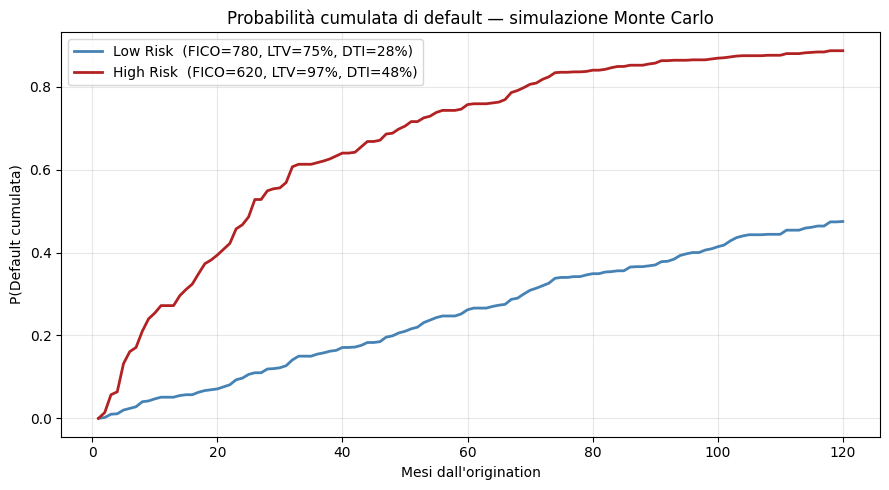

Curva salvata in default_prob_curve.png


In [31]:
def cumulative_default_prob(mc_paths, terminal_state=4, max_time=120):
    """Calcola P(default entro t mesi) per t in [1, max_time]."""
    n = len(mc_paths)
    probs = []
    for t in range(1, max_time + 1):
        defaulted = sum(
            1 for path in mc_paths
            if terminal_state in path.states
            and sum(path.time_at_each_state) <= t
        )
        probs.append(defaulted / n)
    return probs


MAX_T = 120  # 10 anni
t_axis = range(1, MAX_T + 1)

pd_low  = cumulative_default_prob(mc_paths_low,  max_time=MAX_T)
pd_high = cumulative_default_prob(mc_paths_high, max_time=MAX_T)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_axis, pd_low,  label="Low Risk  (FICO=780, LTV=75%, DTI=28%)", color="steelblue", lw=2)
ax.plot(t_axis, pd_high, label="High Risk  (FICO=620, LTV=97%, DTI=48%)", color="firebrick", lw=2)
ax.set_xlabel("Mesi dall'origination")
ax.set_ylabel("P(Default cumulata)")
ax.set_title("Probabilità cumulata di default — simulazione Monte Carlo")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("default_prob_curve.png", dpi=150)
plt.show()
print(f"Curva salvata in default_prob_curve.png")

### 7.5 Simulazione da stato 2 (mutuo già in 30-59 DPD)

In [32]:
print("Simulazione HIGH RISK già in stato 2 (30-59 DPD)...")
mc_paths_stressed = multi_state_model.run_monte_carlo_simulation(
    sample_covariates=profilo_high_risk,
    origin_state=2,
    current_time=6,  # 6 mesi dall'origination
    n_random_samples=N_SIM,
    max_transitions=20,
    print_paths=False,
    n_jobs=-1,
)

freq_stressed = get_path_frequencies(mc_paths_stressed)
print()
print("=== Percorsi più frequenti — HIGH RISK da stato 2 ===")
for path, count in label_path(freq_stressed, STATE_LABELS).items():
    pct = count / N_SIM * 100
    print(f"  {count:4d} ({pct:5.1f}%)  {path}")

Simulazione HIGH RISK già in stato 2 (30-59 DPD)...


100%|██████████| 1000/1000 [00:03<00:00, 263.09it/s]



=== Percorsi più frequenti — HIGH RISK da stato 2 ===
   484 ( 48.4%)  2 → - → > → 1 → - → > → 2 → - → > → 4
   167 ( 16.7%)  2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
   161 ( 16.1%)  2 → - → > → 1 → - → > → 4
   152 ( 15.2%)  2 → - → > → 4
    22 (  2.2%)  2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
    11 (  1.1%)  2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 4
     1 (  0.1%)  2 → - → > → 1 → - → > → 3
     1 (  0.1%)  2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4
     1 (  0.1%)  2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 1 → - → > → 2 → - → > → 4


## 8. Salvataggio del modello e configurazione simulatore

In [33]:
import pickle

with open("freddie_mac_msm.pkl", "wb") as f:
    pickle.dump(multi_state_model, f)
print("Modello salvato in freddie_mac_msm.pkl")

Modello salvato in freddie_mac_msm.pkl


In [34]:
# Ricaricare il modello e configurare il simulatore
with open("freddie_mac_msm.pkl", "rb") as f:
    loaded_model = pickle.load(f)

competing_risks_list = extract_competing_risks_models_list_from_msm(
    loaded_model, verbose=True
)

mssim = MultiStateSimulator(
    competing_risks_list,
    terminal_states=TERMINAL_STATES,
    update_covariates_fn=freddie_update_covariates,
    covariate_names=COVARIATE_COLS,
    state_labels=STATE_LABELS,
)

print("Simulatore configurato correttamente.")

1 3 <pymsm.competing_risks_model.EventSpecificModel object at 0x000001F1C30E2850>
1 4 <pymsm.competing_risks_model.EventSpecificModel object at 0x000001F1C3316590>
1 2 <pymsm.competing_risks_model.EventSpecificModel object at 0x000001F1C3328D50>
2 1 <pymsm.competing_risks_model.EventSpecificModel object at 0x000001F1C3333490>
2 4 <pymsm.competing_risks_model.EventSpecificModel object at 0x000001F1C3341B50>
Simulatore configurato correttamente.


## 9. Prossimi passi suggeriti

| Estensione | Come implementarla |
|---|---|
| **Covariate macro time-varying** | Aggiorna `freddie_update_covariates` con tassi/spread in funzione di `current_time + transition_time` |
| **Cohort analysis** | Filtra per anno di origination e confronta i modelli |
| **PD a 12/24 mesi** | Usa `cumulative_default_prob` per calcolare le PD regolamentari |
| **LGD integration** | Moltiplica P(default) per LGD stimata per ottenere EL |
| **Più mutui per simulazione** | Usa `mssim` per simulare interi portafogli in parallelo |
| **Stato 5: Prepaid** | Se hai dati di prepayment, aggiungi stato terminale 5 |
